#### IMPORTAÇÕES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#### LEITURA DO DATAFRAME

In [2]:
df_spotify = pd.read_csv(r'../data/dataset.csv') 

In [3]:
df_spotify.info()
df_spotify.describe()
df_spotify.head(n=5)

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## ANÁLISE EXPLORATÓRIA

#### QUANTOS VALORES NULOS TEMOS EM CADA FEATURE

In [4]:
qtd_valores_nulos = df_spotify.isnull().sum()


print(f'Valores nulos: {qtd_valores_nulos} ')

Valores nulos: Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64 


#### QUANTOS VALORES DUPLICADOS TEMOS NO DF

In [5]:
qtd_valores_duplicados = df_spotify.duplicated().sum()
print(f'Temos {qtd_valores_duplicados} valores duplicados')

Temos 0 valores duplicados


#### VERIFICAÇÃO DE QUANTIDADE DE GENEROS MUSICAIS

In [6]:
qtd_generos = df_spotify['track_genre'].nunique()
print(f'Temos {qtd_generos} generos musicais')


Temos 114 generos musicais


#### QUANTAS MUSICAS EXISTEM PARA CADA GENERO? 

In [7]:
generos_populares = df_spotify['track_genre'].value_counts()
print(f'{generos_populares}')

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


#### ANÁLISE DAS DISTRIBUIÇÕES

As variáveis musicais apresentam distribuições distintas. Features como danceability, energy, valence e tempo apresentam boa variabilidade, o que pode contribuir para a diferenciação entre músicas no sistema de recomendação.

Já speechiness, instrumentalness e liveness apresentam forte concentração em valores baixos, indicando que a maioria das músicas possui pouca fala, não é instrumental e não corresponde a gravações ao vivo.

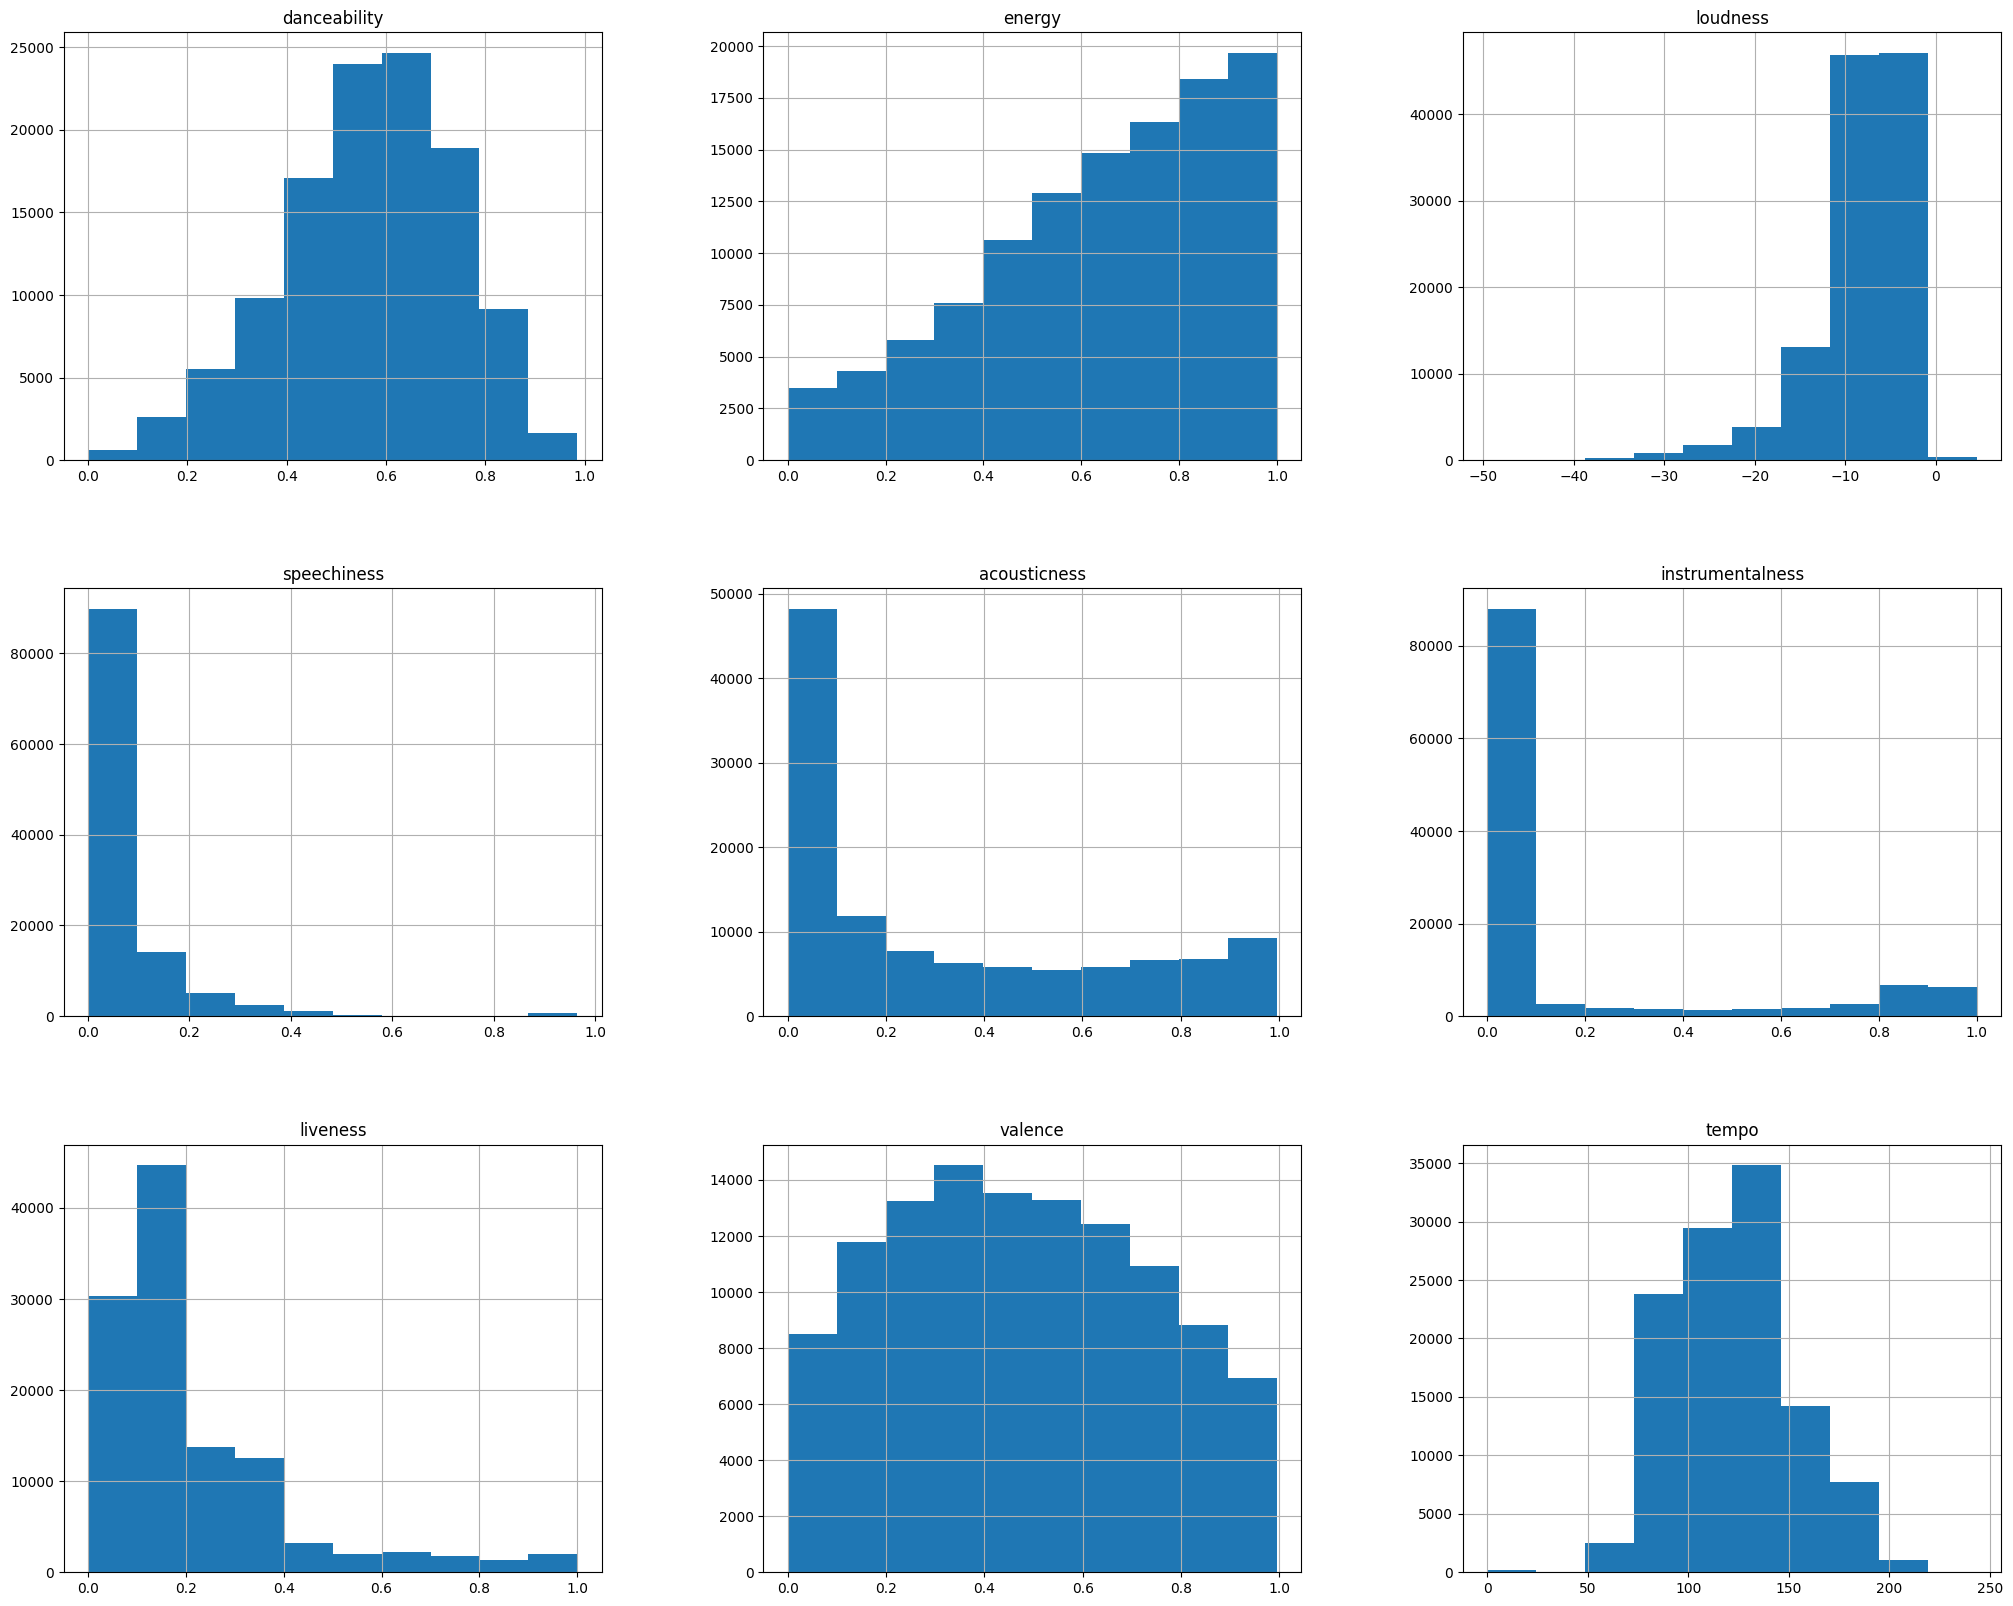

In [8]:
df_spotify.columns

df_spotify[["danceability",
             "energy",
             "loudness",
             "speechiness",
             "acousticness",
             "instrumentalness",
             "liveness",
             "valence",
             "tempo"]].hist(figsize=(25,20))

plt.show()

## LIMPEZA DE DADOS E SELEÇÃO DE FEATURES
Nesta farei a limpeza dos dados, remover colunas desnecessárias, tratar valores nulos e selecionar as variáveis que serão utilizadas pelo sistema de recomendação.

#### REMOÇÃO DE COLUNAS DESNECESSÁRIAS
A coluna `Unnamed: 0` representa apenas um índice salvo no arquivo CSV e não tem utilidade para análise ou modelagem.

In [9]:
df_spotify = df_spotify.drop(columns=['Unnamed: 0'])

df_spotify.shape

(114000, 20)

#### TRATAMENTO DE VALORES NULOS

O dataset possui apenas uma linha com valores nulos nas colunas relacionadas à identificação da música. Como a quantidade é pequena, a linha será removida.

In [10]:
df_spotify = df_spotify.dropna()

df_spotify.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

#### SELEÇÃO DAS FEATURES

Foram selecionadas características de áudio fornecidas pelo Spotify que descrevem aspectos musicais das faixas. 
Essas variaveis serão utilizadas para medir a similaridade entre musicas

In [11]:
display(df_spotify.columns)

features = ["danceability",
            "energy",
            "loudness",
            "speechiness",
            "acousticness",
            "instrumentalness",
            "liveness",
            "valence",
            "tempo"]

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')

#### DATASET PARA MODELAGEM

Criarei um subconjunto contendo apenas as variaveis utilizadas pelo sistema de recomendação

In [12]:
df_modelagem = df_spotify[features]

df_modelagem.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


#### ESCALONAMENTO DAS VARIÁVEIS

As variaveis possuem escalas diferentes. `tempo` pode chegar a valores acima de 180 enquanto algumas variaveis variam apenas entre 0 e 1. Para evitar influencia excessiva no calculo da similaridade, irei padronizar os dados usando o StandardScaler!

In [13]:
sc = StandardScaler()

df_modelagem_escalado = sc.fit_transform(df_modelagem)

In [14]:
df_modelagem_escalado.shape

(113999, 9)

In [15]:
df_modelagem_escalado = pd.DataFrame(data=df_modelagem_escalado,
                                     columns=features)


display(df_modelagem_escalado.round(2))

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.63,-0.72,0.30,0.55,-0.85,-0.50,0.76,0.93,-1.14
1,-0.85,-1.89,-1.78,-0.08,1.83,-0.50,-0.59,-0.80,-1.49
2,-0.74,-1.12,-0.29,-0.27,-0.32,-0.50,-0.51,-1.37,-1.53
3,-1.73,-2.31,-2.04,-0.46,1.77,-0.50,-0.43,-1.28,1.99
4,0.30,-0.79,-0.28,-0.30,0.46,-0.50,-0.69,-1.18,-0.07
...,...,...,...,...,...,...,...,...,...
113994,-2.27,-1.62,-1.62,-0.40,0.98,2.49,-0.67,-1.70,0.13
113995,-2.26,-2.08,-2.00,-0.42,2.04,2.65,-0.57,-1.69,-1.23
113996,0.36,-1.24,-0.52,-0.40,1.66,-0.50,-0.68,1.04,0.34
113997,0.12,-0.54,-0.52,-0.52,0.20,-0.50,0.30,-0.24,0.46


## SEPARAÇÃO DOS DADOS

Em projetos de classificação e regressão normalmente dividimos os dados em conjuntos para treino e teste.

Nesse projeto, estou construindo um sistema de recomendação baseado na similaridade entre músicas. Como não existe um alvo a ser previsto, não farei a divisão dos dados